In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)

number_of_transactions = 10000

data = {
    "transaction_id": [
        f"TXN{i:06d}" for i in range(1, number_of_transactions + 1)
    ],
    "customer_id": [
        f"CUST{np.random.randint(1, 2001):05d}"
        for _ in range(number_of_transactions)
    ],
    "amount": np.round(
        np.random.uniform(500, 500000, number_of_transactions), 2
    ),
    "payment_method": np.random.choice(
        ["Mobile Money", "Bank Transfer", "Card"],
        number_of_transactions
    ),
    "hour": np.random.randint(0, 24, number_of_transactions),
    "location": np.random.choice(
        ["Kampala", "Jinja", "Mbarara", "Gulu", "Mbale"],
        number_of_transactions
    ),
    "device": np.random.choice(
        ["Android", "iPhone", "Web"],
        number_of_transactions
    ),
    "failed_attempts": np.random.poisson(
        0.5, number_of_transactions
    ),
}

df = pd.DataFrame(data)

df.head()



,transaction_id,customer_id,amount,payment_method,hour,location,device,failed_attempts
0,TXN000001,CUST01127,228096.95,Mobile Money,18,Mbarara,iPhone,2
1,TXN000002,CUST01460,241267.66,Mobile Money,14,Jinja,Web,0
2,TXN000003,CUST00861,379009.39,Bank Transfer,22,Gulu,Web,1
3,TXN000004,CUST01295,141318.22,Bank Transfer,0,Gulu,Web,0
4,TXN000005,CUST01131,159360.79,Mobile Money,16,Jinja,Web,0


In [3]:
df["is_fraud"] = 0

fraud_condition = (
    (df["amount"] > 400000) &
    (df["hour"].isin([0, 1, 2, 3, 4]))
) | (
    df["failed_attempts"] >= 4
)

df.loc[fraud_condition, "is_fraud"] = 1

df["is_fraud"].value_counts()

is_fraud
0    9618
1     382
Name: count, dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transaction_id   10000 non-null  str    
 1   customer_id      10000 non-null  str    
 2   amount           10000 non-null  float64
 3   payment_method   10000 non-null  str    
 4   hour             10000 non-null  int64  
 5   location         10000 non-null  str    
 6   device           10000 non-null  str    
 7   failed_attempts  10000 non-null  int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 625.1 KB


In [6]:
df.describe()

,amount,hour,failed_attempts
count,10000.000000,10000.0000,10000.000000
mean,248328.701657,11.6203,0.501400
std,144036.396603,6.8733,0.710668
min,526.390000,0.0000,0.000000
25%,123592.762500,6.0000,0.000000
50%,245526.750000,12.0000,0.000000
75%,374344.287500,18.0000,1.000000
max,499902.670000,23.0000,5.000000


In [7]:
df.isnull().sum()

transaction_id     0
customer_id        0
amount             0
payment_method     0
hour               0
location           0
device             0
failed_attempts    0
dtype: int64

In [13]:
df.columns

Index(['transaction_id', 'customer_id', 'amount', 'payment_method', 'hour',
       'location', 'device', 'failed_attempts'],
      dtype='str')

In [16]:
df["is_fraud"] = 0

fraud_condition = (
    (df["amount"] > 400000) &
    (df["hour"].isin([0, 1, 2, 3, 4]))
) | (
    df["failed_attempts"] >= 4
)

df.loc[fraud_condition, "is_fraud"] = 1

In [17]:
df["is_fraud"].value_counts()

is_fraud
0    9618
1     382
Name: count, dtype: int64

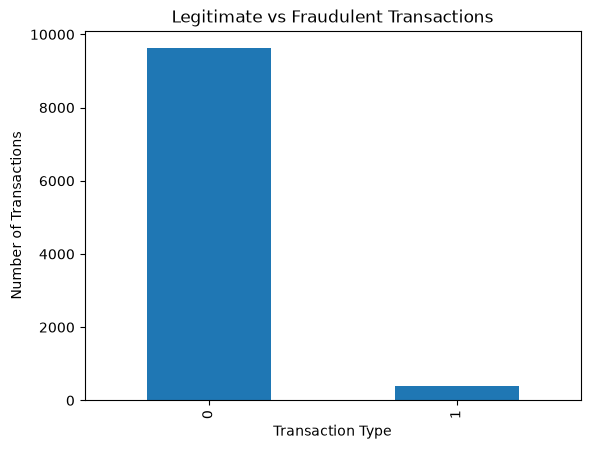

In [18]:
import matplotlib.pyplot as plt

df["is_fraud"].value_counts().plot(kind="bar")

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.show()

In [19]:
df.groupby("is_fraud")["amount"].mean()

is_fraud
0    240822.205923
1    437327.329843
Name: amount, dtype: float64

In [20]:
pd.crosstab(
    df["payment_method"],
    df["is_fraud"]
)

is_fraud,0,1
payment_method,,
Bank Transfer,3176,146
Card,3205,110
Mobile Money,3237,126


In [21]:
model_df = pd.get_dummies(
    df,
    columns=[
        "payment_method",
        "location",
        "device"
    ],
    dtype=int
)

model_df.head()

,transaction_id,customer_id,amount,hour,failed_attempts,is_fraud,payment_method_Bank Transfer,payment_method_Card,payment_method_Mobile Money,location_Gulu,location_Jinja,location_Kampala,location_Mbale,location_Mbarara,device_Android,device_Web,device_iPhone
0,TXN000001,CUST01127,228096.95,18,2,0,0,0,1,0,0,0,0,1,0,0,1
1,TXN000002,CUST01460,241267.66,14,0,0,0,0,1,0,1,0,0,0,0,1,0
2,TXN000003,CUST00861,379009.39,22,1,0,1,0,0,1,0,0,0,0,0,1,0
3,TXN000004,CUST01295,141318.22,0,0,0,1,0,0,1,0,0,0,0,0,1,0
4,TXN000005,CUST01131,159360.79,16,0,0,0,0,1,0,1,0,0,0,0,1,0


In [22]:
features = [
    "amount",
    "hour",
    "failed_attempts"
]

features += [
    column
    for column in model_df.columns
    if column.startswith("payment_method_")
    or column.startswith("location_")
    or column.startswith("device_")
]

X = model_df[features]
y = model_df["is_fraud"]

In [23]:
X.head()

,amount,hour,failed_attempts,payment_method_Bank Transfer,payment_method_Card,payment_method_Mobile Money,location_Gulu,location_Jinja,location_Kampala,location_Mbale,location_Mbarara,device_Android,device_Web,device_iPhone
0,228096.95,18,2,0,0,1,0,0,0,0,1,0,0,1
1,241267.66,14,0,0,0,1,0,1,0,0,0,0,1,0
2,379009.39,22,1,1,0,0,1,0,0,0,0,0,1,0
3,141318.22,0,0,1,0,0,1,0,0,0,0,0,1,0
4,159360.79,16,0,0,0,1,0,1,0,0,0,0,1,0


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [27]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1924
           1       1.00      0.99      0.99        76

    accuracy                           1.00      2000
   macro avg       1.00      0.99      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [28]:
risk_scores = model.predict_proba(X_test)[:, 1]

results = X_test.copy()

results["actual_fraud"] = y_test.values
results["risk_score"] = risk_scores

results.head()

,amount,hour,failed_attempts,payment_method_Bank Transfer,payment_method_Card,payment_method_Mobile Money,location_Gulu,location_Jinja,location_Kampala,location_Mbale,location_Mbarara,device_Android,device_Web,device_iPhone,actual_fraud,risk_score
7683,217774.60,4,1,0,0,1,0,0,0,0,1,0,1,0,0,0.0
4603,359370.86,15,1,0,1,0,0,0,1,0,0,0,1,0,0,0.0
9740,252266.98,5,0,0,0,1,0,0,0,1,0,0,0,1,0,0.0
4437,318930.65,9,0,0,0,1,0,0,0,0,1,0,0,1,0,0.0
7648,380956.62,13,0,1,0,0,0,0,0,1,0,0,0,1,0,0.0


In [30]:
results["risk_percentage"] = (
    results["risk_score"] * 100
).round(2)

results.head()

,amount,hour,failed_attempts,payment_method_Bank Transfer,payment_method_Card,payment_method_Mobile Money,location_Gulu,location_Jinja,location_Kampala,location_Mbale,location_Mbarara,device_Android,device_Web,device_iPhone,actual_fraud,risk_score,risk_percentage
7683,217774.60,4,1,0,0,1,0,0,0,0,1,0,1,0,0,0.0,0.0
4603,359370.86,15,1,0,1,0,0,0,1,0,0,0,1,0,0,0.0,0.0
9740,252266.98,5,0,0,0,1,0,0,0,1,0,0,0,1,0,0.0,0.0
4437,318930.65,9,0,0,0,1,0,0,0,0,1,0,0,1,0,0.0,0.0
7648,380956.62,13,0,1,0,0,0,0,0,1,0,0,0,1,0,0.0,0.0


In [31]:
import joblib

joblib.dump(
    model,
    "../models/fraud_detection_model.pkl"
)

['../models/fraud_detection_model.pkl']

In [32]:
df.to_csv("../data/processed/securepay_transactions.csv", index=False)